---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
</div>

---

## Organização deste notebook

Este material foi estruturado em **5 partes**, com explicações objetivas sobre os passos tomados em cada etapa do fluxo de treinamento de uma regressão linear.

In [1]:
# numpy para cálculos matemáticos
# matplotlib para visualização de dados

import numpy as np
import matplotlib.pyplot as plt

# Parte 1: Preparação do problema e geração do dataset

Nesta etapa, criamos um conjunto de dados sintético para regressão linear (`y = w*x + b + ruído`).

**Passos desta parte:**
1. Definir a função que gera os dados com ruído controlado.
2. Criar os vetores de entrada (`x`) e saída alvo (`y`).
3. Plotar os dados para visualizar o padrão linear antes do treinamento.

---

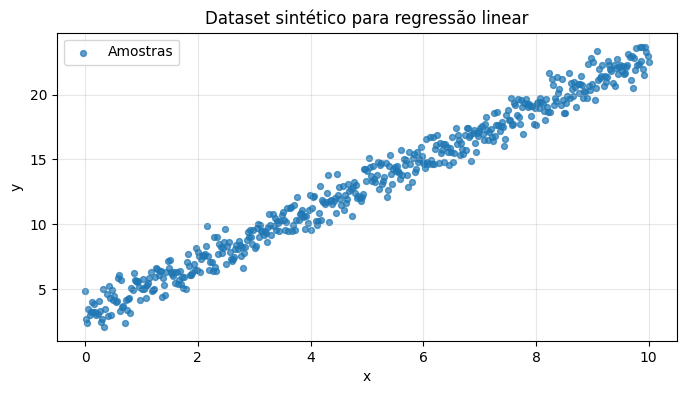

In [2]:
# Gera dados de regressão linear com ruído controlado

def create_dataset(x, w, b=3.0, noise_std=0.3):
    noise = np.random.normal(loc=0.0, scale=noise_std, size=x.shape[0])
    return w * x + b + noise

x = np.linspace(0, 10, 500)
y = create_dataset(x, w=2.0, b=3.0, noise_std=0.8)

plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=18, alpha=0.7, label="Amostras")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset sintético para regressão linear")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Parte 2: Inicialização dos parâmetros

Antes de treinar, iniciamos os parâmetros do modelo:
- `w` (peso) com valor aleatório;
- `b` (bias) com valor inicial zero.

**Objetivo:** começar com um estado inicial e acompanhar como esses valores são ajustados pelo gradiente durante as épocas.

In [3]:
# inicializar os pesos e bias

w = float(np.random.randn())
b = 0.0

print(f"Pesos iniciais: w = {w:.4f}, b = {b:.4f}")

Pesos iniciais: w = 0.7415, b = 0.0000


## Parte 3: Construção da base matemática do modelo

Aqui definimos as funções que compõem o treinamento:

- **Forward propagation**: calcula a predição `y_pred = w*x + b`.
- **MSE (Mean Squared Error)**: mede o erro médio quadrático entre `y_true` e `y_pred`.
- **Backward propagation**: calcula os ajustes de `w` e `b` com gradiente descendente.
- **Função de treino (`model_fit`)**: executa o loop de épocas, atualiza parâmetros e salva o histórico de perda.

**Passos tomados:**
1. Predizer com os parâmetros atuais.
2. Calcular o erro.
3. Atualizar os parâmetros.
4. Repetir por várias épocas e registrar a evolução.

### Equações do modelo: Forward, Loss e Backward

Nesta seção, formalizamos matematicamente o que as funções do código fazem.

**Forward propagation (predição):**

$$
\hat{y}_i = w x_i + b
$$

Para o conjunto com $N$ amostras:

$$
\hat{\mathbf{y}} = w\mathbf{x} + b
$$

**Função de custo (MSE):**

$$
\mathcal{L}(w,b) = \frac{1}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2
= \frac{1}{N}\sum_{i=1}^{N}(y_i-(w x_i + b))^2
$$

**Derivada em relação a $w$:**

$$
\frac{\partial \mathcal{L}}{\partial w} = -\frac{2}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)x_i
$$

**Derivada em relação a $b$:**

$$
\frac{\partial \mathcal{L}}{\partial b} = -\frac{2}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)
$$

**Atualização dos parâmetros (gradiente descendente):**

$$
w \leftarrow w - \eta\frac{\partial \mathcal{L}}{\partial w},
\qquad
b \leftarrow b - \eta\frac{\partial \mathcal{L}}{\partial b}
$$

onde $\eta$ é a taxa de aprendizado (*learning rate*).

No código, isso aparece no `backward_propagation` com os termos médios do gradiente e atualização de `w` e `b` a cada época.

In [4]:
def forward_propagation(inputs, w, b):
    # Para regressão linear simples: y_pred = w*x + b
    return w * inputs + b

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [5]:
def backward_propagation(inputs, outputs, targets, w, b, lr):
    dw = lr*(-2*(targets-outputs)*inputs).mean()
    db = lr*(-2*(targets-outputs)).mean()

    w = w - dw
    b = b - db

    return w, b

In [6]:
def model_fit(inputs, targets, w, b, lr=0.001, epochs=200):
    history = []

    for epoch in range(epochs):
        outputs = forward_propagation(inputs, w, b)
        cost = mse(targets, outputs)
        w, b = backward_propagation(inputs, outputs, targets, w, b, lr)
        history.append(cost)

        if epoch % 50 == 0:
            print(f"Epoch {epoch:03d}, loss = {cost:.4f}, w = {w:.4f}, b = {b:.4f}")

    return w, b, history

## Parte 4: Execução do treinamento

Nesta parte, executamos o `model_fit` para ajustar os parâmetros do modelo.

**Passos da execução:**
1. Reinicializar `w` e `b` para iniciar um novo treinamento.
2. Chamar `model_fit` com `x`, `y`, taxa de aprendizado (`lr`) e número de épocas.
3. Acompanhar os logs de época para observar a redução da loss.

**Resultado esperado:** perda diminuindo e parâmetros convergindo para valores que representem bem os dados.

In [7]:
w = float(np.random.randn())
b = 0.0

w, b, history = model_fit(inputs = x, 
                          targets = y, 
                          w = w,
                          b = b,
                          lr = 0.001,
                          epochs = 1000)

Epoch 000, loss = 83.6941, w = 1.0050, b = 0.0171
Epoch 050, loss = 2.6568, w = 2.3727, b = 0.2939
Epoch 100, loss = 2.4958, w = 2.4028, b = 0.3670
Epoch 150, loss = 2.4081, w = 2.3941, b = 0.4326
Epoch 200, loss = 2.3246, w = 2.3845, b = 0.4964
Epoch 250, loss = 2.2452, w = 2.3751, b = 0.5587
Epoch 300, loss = 2.1695, w = 2.3660, b = 0.6195
Epoch 350, loss = 2.0975, w = 2.3570, b = 0.6788
Epoch 400, loss = 2.0289, w = 2.3483, b = 0.7367
Epoch 450, loss = 1.9636, w = 2.3397, b = 0.7932
Epoch 500, loss = 1.9015, w = 2.3314, b = 0.8483
Epoch 550, loss = 1.8423, w = 2.3233, b = 0.9021
Epoch 600, loss = 1.7859, w = 2.3154, b = 0.9545
Epoch 650, loss = 1.7322, w = 2.3077, b = 1.0057
Epoch 700, loss = 1.6812, w = 2.3001, b = 1.0557
Epoch 750, loss = 1.6325, w = 2.2928, b = 1.1044
Epoch 800, loss = 1.5862, w = 2.2856, b = 1.1520
Epoch 850, loss = 1.5421, w = 2.2786, b = 1.1984
Epoch 900, loss = 1.5001, w = 2.2717, b = 1.2437
Epoch 950, loss = 1.4601, w = 2.2651, b = 1.2879


## Parte 5: Visualização e análise dos resultados

Após o treinamento, avaliamos o comportamento do modelo em dois gráficos:

1. **Dados reais + reta aprendida**: mostra o ajuste final.
2. **Curva da loss (MSE)**: mostra se o modelo convergiu durante as épocas.

Por fim, exibimos o **MSE final** para ter uma métrica numérica do erro residual.

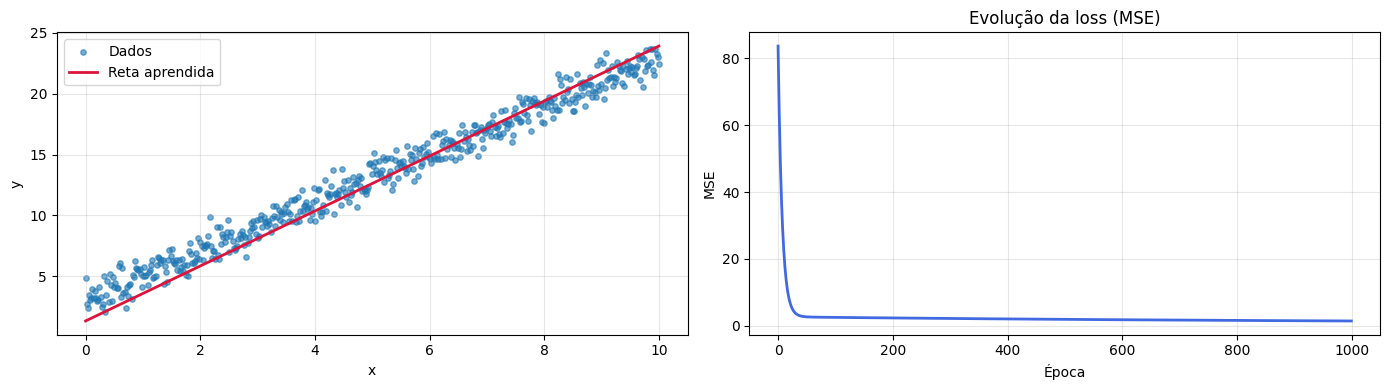

MSE final: 1.422787


In [8]:
# Plot 1: dados + reta aprendida
# Plot 2: evolução do erro (loss)

y_pred = forward_propagation(x, w, b)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Dados e reta ajustada
axes[0].scatter(x, y, s=15, alpha=0.6, label="Dados")
axes[0].plot(x, y_pred, color="crimson", linewidth=2, label="Reta aprendida")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Curva de loss
axes[1].plot(history, color="royalblue", linewidth=2)
axes[1].set_title("Evolução da loss (MSE)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MSE final: {history[-1]:.6f}")